# SuSteelAible — NLP Pipeline
**Contributors:** [@am0ebe](https://github.com/am0ebe) · [@MJR-data](https://github.com/MJR-data) | **Focus:** Decarbonization barriers & motivators in EU steel sustainability reports (2013–2025)

## Pipeline Overview

```
data/reports/ (PDFs)
    ↓ [1] ClimateBERT        → cache/*_prep.json, cache/*_bert.json
    ↓ [2] BERT Visualization → out/company_year.csv, plots
    ↓ [3] RAG Extraction     → out/barriers_*.csv, out/motivators_*.csv
    ↓ [4] Topic Modeling     → out/topics/
```

Each step caches its output — rerunning skips completed work automatically.

**Before running sections 3 & 4:** add `GROQ_API_KEY=<your-key>` to a `.env` file in the project root.

## 1. ClimateBERT — Filter & Score Chunks

Processes every PDF through 5 ClimateBERT classifiers:
- **detector**: is this chunk climate-related? (pre-filter for later steps)
- **specificity**: concrete vs. vague language?
- **commitment**: does the company commit to action?
- **sentiment**: opportunity / neutral / risk framing?
- **netzero**: net-zero reduction language?

**Input:** `data/reports/` (PDFs), translated to English if needed  
**Output:** `cache/*_prep.json` (chunks), `cache/*_bert.json` (+ BERT scores per chunk)  
**Time:** slow on first run (GPU recommended) — subsequent runs load from cache instantly.

Only chunks classified as climate-related by the detector pass through to later steps.

In [ ]:
from nlp import analyze_reports

stats = analyze_reports('../data/reports/Baosteel')
# stats = analyze_reports("../data/reports")

## 2. BERT Visualization & Export

Aggregates BERT scores across all cached reports and produces:
- **CSVs** in `out/bert/`: `company_year.csv`, `company_totals.csv`, `yearly_industry.csv`
- **Plots** in `out/bert/`: talk score trends, sentiment trajectories, net-zero funnel, word clouds

**Talk Score** = 20% climate volume + 40% specificity + 40% commitment (0–100 composite)

Years ≥ 2025 are excluded by default (incomplete reporting cycle skews trends).

**Check:** `out/bert/` — open `talk_score_trend.png` and `wordclouds.png` for a quick sanity check on coverage and tone.

In [ ]:
from nlp import visualize_results

visualize_results("../cache", "../out")

✅ Loaded: 193 reports, 15 companies, 2013-2024

EXPORTING CSV FILES
   ✓ company_year.csv (129 rows)
   ✓ company_totals.csv (15 companies)
   ✓ yearly_industry.csv (12 years)
   ✓ funnel_company_year.csv (129 rows)

   📁 All CSVs saved to: ../out/

GENERATING PLOTS
   ✓ slide_main.png
   ✓ slide_sentiment_trend.png
   ✓ talk_score_trend.png
   ✓ funnel_trend.png
   ✓ talk_score_per_company.png
   ✓ per_company_components.png
   ✓ per_company_sentiment.png
   ✓ sentiment_all_companies.png
   ✓ n0_funnel.png
   ✓ n0_quality_comparison.png
   ✓ n0_per_company.png
   ✓ n0_gap_analysis.png

   📁 All plots saved to: ../out/

   Generating word frequency plots...

   📊 ALL CHUNKS (top 30):
   environment(17950), sustainable(17493), production(16608), emission(14006), management(13797), energy(12048), financial(11688), development(11410), business(11035), reduction(10864), products(9790), million(9437), carbon(9152), iron(8384), process(6902)

   🌱 OPPORTUNITY chunks (top 15):
   production(7

## 3. RAG Extraction — Barriers & Motivators

Uses retrieval-augmented generation to extract specific barriers and motivators from each company-year report:

1. All BERT-filtered chunks are embedded (Snowflake arctic-embed-s) and indexed in FAISS
2. For each company × year, 3 queries per category retrieve the most relevant chunks (MMR for diversity)
3. Retrieved chunks (~20) are sent to an LLM which extracts bullet-point barriers/motivators

**Why RAG over exhaustive?** Exhaustive batching hit Groq rate limits and had variable match rates (30–70%). RAG focuses the LLM on relevant content and uses far fewer API calls.

**Output:** `out/barriers_{id}.csv`, `out/motivators_{id}.csv` — one file per company  
**Resume:** `extract_all_companies(resume=True)` skips companies with existing CSVs.  
Set `reuse_faiss_cache=True` after first run to skip re-embedding.

**Check:** open a couple of `out/barriers_*.csv` files and skim the extracted text — look for specificity and relevance. Vague or off-topic extractions indicate the retrieval queries or LLM prompt may need tuning.

### Model Testing (optional — skip if using defaults)

In [ ]:
from nlp.test import save_test_results, test_models, compare_extractions
from nlp import Config

# Available models (for reference):
# Groq:   mixtral-8x7b-32768, gemma2-9b-it
# Ollama: gemma3:4b

MODELS = [

    # RAG approach
    Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="rag", ctx=128000, top_k=20, reuse_faiss_cache=False),

    # Exthaustive approach
    # Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="exhaustive", ctx=128000, batch_size=3),  # free tier: 6k TPM - test batch_size
    # Config(llm_provider="ollama", model="qwen2.5:3b", approach="exhaustive", ctx=4096),  # 1.9GB - FAIL format
    # Config(llm_provider="ollama", model="qwen3:4b", approach="exhaustive", ctx=2048),     # 2.5GB - too slow. was generating alot of hidden thinking tokens
    # Config(llm_provider="ollama", model="gemma3:4b", approach="exhaustive", ctx=4096),   # 3.3GB - PASS but slow
    # Config(llm_provider="ollama", model="llama3.2:3b", approach="exhaustive", ctx=4096),  # too small for quality
    # Config(llm_provider="ollama", model="llama3.1:8b ", approach="exhaustive", ctx=4096),  # too big for local VRAM

]

results = test_models(MODELS, skip_extraction=False)
compare_extractions(results)
save_test_results(results)

### Setup & Run Pipeline

In [ ]:
from nlp import load_pipeline, Config

config = Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="rag", ctx=128000, top_k=20, reuse_faiss_cache=True)
# Exhaustive (all chunks batched through LLM)
# config = Config(llm_provider="groq", model="llama-3.1-8b-instant", approach="exhaustive", ctx=128000, batch_size=3)
# config = Config(llm_provider="ollama", model="llama3.2:3b", approach="exhaustive", ctx=4096)

pipeline = load_pipeline(config)
pipeline.print_chunk_overview()

### Run Extraction

In [4]:
results = pipeline.extract_all_companies(resume=True)


EXTRACTION RUN
  LLM: groq/llama-3.1-8b-instant
  Context: 128,000 tokens → 72 chunks/batch
  Chunks: 15593 (1750 avg chars, 38-19629 range)
  Groups: 132 | Est. LLM calls: 568
  Resuming: 13 companies skipped (CSVs exist), 2 remaining


Extracting: AcciaieriedItalia (009)
Years: ['2021', '2022']
Retrieval: top_k=20, strategy=mmr


  009:   0%|          | 0/2 [00:00<?, ?it/s]

Loading Groq: llama-3.1-8b-instant


    B done: 5 found in 1 batches (0.5s)          
  ✓ Extracted 5 barriers, 0 motivators

Extracting: TataSteelUK (010)
Years: ['2021', '2022', '2023', '2024']
Retrieval: top_k=20, strategy=mmr


  ✓ Extracted 0 barriers, 0 motivators

✓ EXTRACTION COMPLETE
  Time: 1.0s (0.0min)
  Results: 1698 barriers, 1255 motivators
  Resumed: 13 companies from cache
  Saved: ../out/stats.json



## 4. Topic Modeling — Cluster Barriers & Motivators

Groups extracted barriers/motivators into coherent themes using BERTopic:
- **Embedding**: sentence transformer → high-dim semantic vectors
- **UMAP**: compress to lower dimensions (preserving cluster structure)
- **HDBSCAN**: density-based clustering (no fixed topic count)
- **c-TF-IDF**: extract representative keywords per cluster
- **LLM labeling**: keywords → human-readable topic labels (batched, one LLM call)

**Why grid search?** HDBSCAN and UMAP params interact non-linearly. The 3-stage search (embedding → HDBSCAN → UMAP) narrows the space efficiently. DBCV measures cluster quality geometrically — but always sanity-check actual topic words.

**Output:** `out/topics/run_XX/` (auto-incremented per run)
- `barriers_labels.csv`, `motivators_labels.csv` — topic ID, label, keyword, doc count
- `barriers_topics.csv`, `motivators_topics.csv` — each extracted item with its assigned topic
- `barriers_*.html`, `motivators_*.html` — interactive visualizations (barchart, documents, hierarchy, heatmap)
- `barriers_datamap.png`, `motivators_datamap.png` — 2D cluster map

**Check:** open `barriers_labels.csv` to see if topics are coherent and well-named. Then open `barriers_documents.html` in a browser to explore the cluster layout interactively.

### Grid Search (run once, then lock params)

Staged tuning — each stage narrows the search space for the next.
- **Stage 1**: Embedding model (manual, ~30s encode each — pick 2-3 candidates)
- **Stage 2**: HDBSCAN structure (eom/leaf × min_cluster_size — the biggest knob)
- **Stage 3**: UMAP geometry (n_components × n_neighbors — secondary but real impact)

In [ ]:
from nlp import TopicGridSearch
gs = TopicGridSearch(data_folder="../out", output_folder="../out/topics")

s1 = gs.stage1_embeddings([
    # Strong clustering (MTEB clustering score in parens)
    # (model, batch_size[, dtype]) — batch_size affects speed/size, not embedding values

    ("KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5", 32),  # (59.3) 1.9GB
    ("Tarka-AIR/Tarka-Embedding-150M-V1", 64), # (56.4) surprisingly strong, 576MB
    ("ibm-granite/granite-embedding-english-r2", 64),  # (50.8) English-only, 284MB >> WINNER:)
    ("BAAI/bge-small-en-v1.5",          64),   # (39.9) fast, 127MB
    ("Snowflake/snowflake-arctic-embed-s", 64), # (33.8) high aggregate MTEB rank but weak on clustering
    ("sentence-transformers/all-mpnet-base-v2", 64),   # (31.9) STS model, weak for clustering

    # Dropped — model weights alone fill the 3.63GB GPU
    # ("Qwen/Qwen3-Embedding-0.6B",       16),   # (52.3) decoder-only. no fit.
    # ("codefuse-ai/F2LLM-0.6B",16),    # not fitting to design test steps.
    # ("codefuse-ai/F2LLM-1.7B", 4),  # (68.5) OOM even with bfloat16 — MTEB 3.2GB already reflects bfloat16 weights (1.72B×2bytes); ~3.47GB on GPU leaves no headroom
])

In [ ]:
gs.locked["embedding_model"] = "ibm-granite/granite-embedding-english-r2"
param_grid = {
    "hdbscan_min_cluster_size": [8, 12, 16, 20, 25, 30, 40],
    "hdbscan_cluster_selection_method": ["eom", "leaf"],
    "hdbscan_min_samples": [2, 3, 5],
}
s2 = gs.stage2_hdbscan(param_grid=param_grid)

In [ ]:
s3 = gs.stage3_umap()
print(gs.category_overrides)
# Paste the best found params into TopicModelConfig(category_overrides=...) in the main pipeline cell below

In [ ]:
from nlp import TopicModelConfig, run_topic_modeling_pipeline

# Best params from grid search (gs_stage1/2/3)
config = TopicModelConfig(
    # Embedding model
    embedding_model="ibm-granite/granite-embedding-english-r2",
    batch_size=64,

    # -> override base defaults per category (see TopicModelConfig in topic_modelling.py)
    category_overrides={
        "barriers": {
            "hdbscan_min_cluster_size": 25,
            "hdbscan_min_samples": 5,
            "hdbscan_cluster_selection_method": "eom",
            "umap_n_components": 5,
            "umap_n_neighbors": 15,
        },
        "motivators": {
            "hdbscan_min_cluster_size": 16,
            "hdbscan_min_samples": 3,
            "hdbscan_cluster_selection_method": "eom",
            "umap_n_components": 5,
            "umap_n_neighbors": 25,
        },
    },
)

results = run_topic_modeling_pipeline(
    data_folder="../out",
    output_folder="../out/topics",
    config=config,
)

barriers_df = results['barriers']['df']
motivators_df = results['motivators']['df']
RUN_DIR = results["output_path"]
print(f"📁 RUN_DIR: {RUN_DIR}")

### Merge Topics (manual post-processing)

Review `barriers_labels.csv` and `motivators_labels.csv` in the run directory, then specify which topic IDs to merge below.

After `merge_topics`, BERTopic keeps the **lowest ID** in each group (e.g. merging `[7, 9, 12, 13]` → topic 7). Topics not listed are unchanged.

Re-running with different groups is safe — the original model is never overwritten.

In [ ]:
from nlp import merge_topics_pipeline, TopicModelConfig, aggregate_by_year, aggregate_by_company_year, latest_run_dir
import pandas as pd

# Use RUN_DIR set by TM cell above; if running standalone fall back to latest run
if "RUN_DIR" not in dir():
    RUN_DIR = latest_run_dir("../out/topics")
print(f"RUN_DIR: {RUN_DIR}")

print("=== BARRIERS ===")
print(pd.read_csv(f"{RUN_DIR}/barriers_labels.csv")[["topic_id", "label", "doc_count"]].to_string(index=False))
print("\n=== MOTIVATORS ===")
print(pd.read_csv(f"{RUN_DIR}/motivators_labels.csv")[["topic_id", "label", "doc_count"]].to_string(index=False))

🖥️  GPU: NVIDIA T1200 Laptop GPU (3.9GB)
✅ Loaded model from ../out/topics/run_04/barriers_model
✅ Loaded embeddings from ../out/topics/run_04/barriers_embeddings.npy

📊 Topics before merge: 21
🔀 Merging 2 group(s):
  [7, 9]
  [12, 13]
✅ Topics after merge: 19

🏷️  Generating 19 topic labels with LLM (single batch)...
Loading Groq: llama-3.1-8b-instant
  Topic 0: Limited Carbon Steel Availability
  Topic 1: Carbon Certification & Labeling Costs
  Topic 2: Industrial Waste Treatment Complexity
  Topic 3: Decarbonisation Investment & Research Costs
  Topic 4: Hydrogen Treatment Plant Experience
  Topic 5: Carbon Climate Policy Complexity
  Topic 6: Carbon Technologies Integration Challenges
  Topic 7: Managing Gas Emissions Complexity
  Topic 8: Hydrogen Fuel Transition Costs
  Topic 9: Renewable Energy Availability Limitations
  Topic 10: Carbon Materials Supply Chain
  Topic 11: Industrial Carbon Emissions Reduction
  Topic 12: Climate Change Mitigation Costs
  Topic 13: Energy Consump

12it [00:22,  1.85s/it]


  ✓ barriers_over_time.html


14it [00:22,  1.62s/it]


  ✓ barriers_per_company.html
  ✓ barriers_datamap.png
✓ Saved updated labels, topics CSV, and visualizations to ../out/topics/run_04
🖥️  GPU: NVIDIA T1200 Laptop GPU (3.9GB)
✅ Loaded model from ../out/topics/run_04/motivators_model
✅ Loaded embeddings from ../out/topics/run_04/motivators_embeddings.npy

📊 Topics before merge: 24
🔀 Merging 3 group(s):
  [0, 2, 12]
  [3, 13]
  [6, 7]
✅ Topics after merge: 20

🏷️  Generating 20 topic labels with LLM (single batch)...
Loading Groq: llama-3.1-8b-instant
  Topic 0: Reducing Steel Emissions
  Topic 1: Achieving Carbon Neutrality
  Topic 2: Sustainable Development Goals
  Topic 3: Environmental Compliance Management
  Topic 4: Decarbonizing the Carbon Future
  Topic 5: Addressing Climate Change
  Topic 6: Energy Efficiency Optimization
  Topic 7: Community Engagement Strategies
  Topic 8: Employee Satisfaction Surveys
  Topic 9: Technological Breakthroughs Development
  Topic 10: 
  Topic 11: Sustainable Supply Chain Practices
  Topic 12: Low

13it [00:26,  2.04s/it]


  ✓ motivators_over_time.html


13it [00:25,  1.94s/it]


  ✓ motivators_per_company.html
  ✓ motivators_datamap.png
✓ Saved updated labels, topics CSV, and visualizations to ../out/topics/run_04
✓ barriers: aggregation CSVs saved
✓ motivators: aggregation CSVs saved


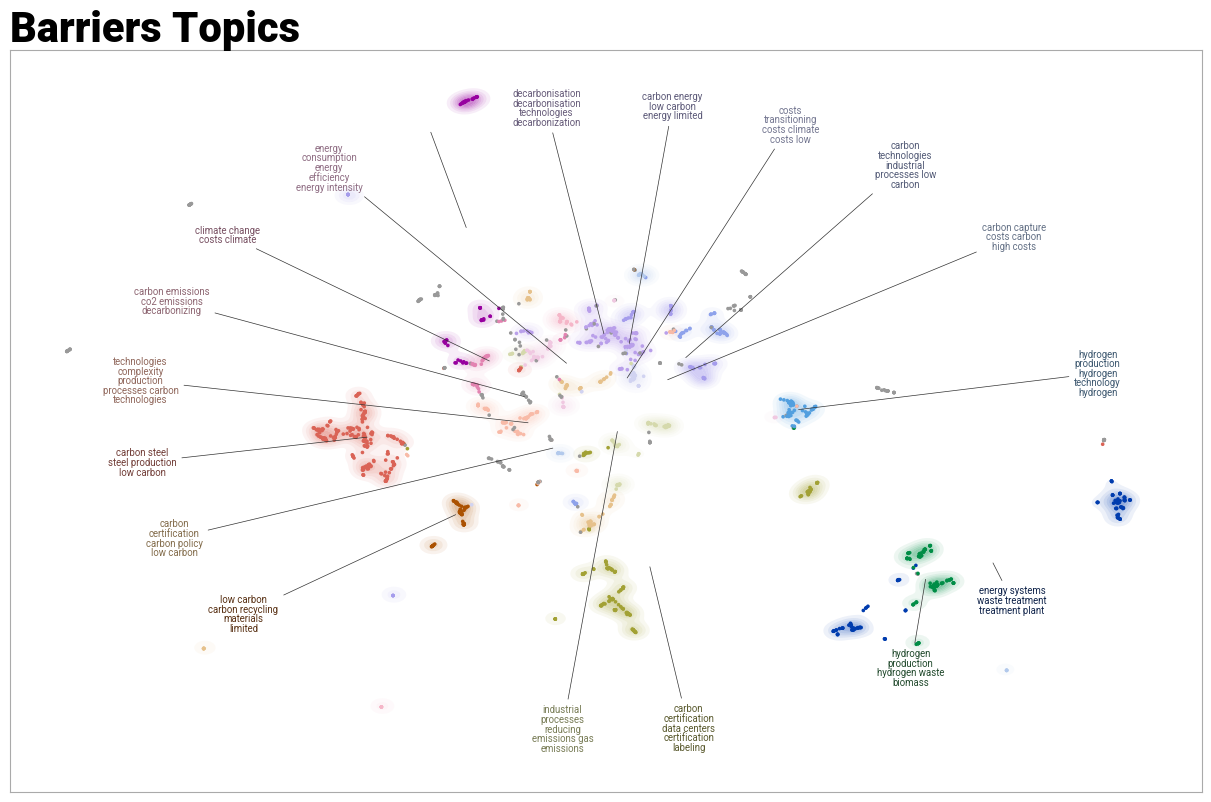

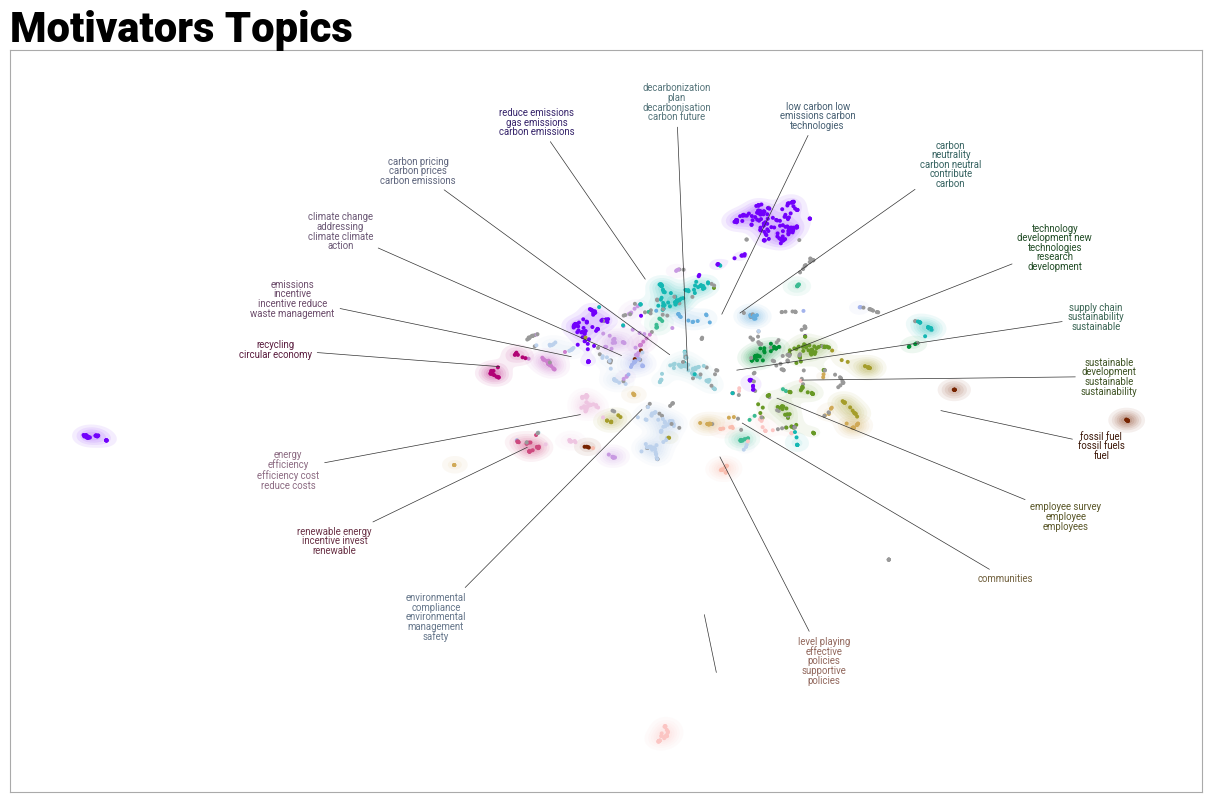

In [ ]:
config = TopicModelConfig(
    embedding_model="ibm-granite/granite-embedding-english-r2",
    llm_provider="groq",
    model="llama-3.1-8b-instant",
)

# -- BARRIERS --
# Suggested merges based on run_04 labels — review and adjust before running.
# Each inner list = topics to collapse into one (lowest ID is kept).
barriers_merges = [
    [6,9,12,13],
    [18,2,17,4,0],
    [8,11,10,3,1],
]
    # [20,5]

barriers_df = merge_topics_pipeline(
    run_dir=RUN_DIR,
    category="barriers",
    topics_to_merge=barriers_merges,
    config=config,
)

# -- MOTIVATORS --
motivators_merges = [
    [19,8,16,2,12,20],
]

motivators_df = merge_topics_pipeline(
    run_dir=RUN_DIR,
    category="motivators",
    topics_to_merge=motivators_merges,
    config=config,
)

# Save aggregations (yearly + company_year go stale after merging — regenerate them)
for category, df in [("barriers", barriers_df), ("motivators", motivators_df)]:
    if "year" in df.columns:
        aggregate_by_year(df).to_csv(f"{RUN_DIR}/{category}_yearly.csv")
    if "company" in df.columns and "year" in df.columns:
        aggregate_by_company_year(df).to_csv(f"{RUN_DIR}/{category}_company_year.csv")
    print(f"✓ {category}: aggregation CSVs saved")